# Project Deliverable 2: Regression Modeling and Performance Evaluation

**Dataset:** UCI Red Wine Quality dataset

## Assignment
This deliverable extends Deliverable 1 by performing feature engineering, building at least two regression models, evaluating them with R-squared/MSE/RMSE, using cross-validation, and summarizing which model performed best.

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import r2_score, mean_squared_error

SCREENSHOTS = Path('screenshots')
SCREENSHOTS.mkdir(exist_ok=True)
wine = pd.read_csv('data/winequality-red-cleaned-project-d1.csv')
print(wine.shape)
wine.head()

(1359, 12)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.66,0.00,1.8,0.075,13.0,40.0,0.9978,3.51,0.56,9.4,5


In [2]:
# Feature engineering: preserve original variables and add interpretable chemistry ratios/interactions.
wine_fe = wine.copy()
wine_fe['free_to_total_sulfur_ratio'] = wine_fe['free sulfur dioxide'] / wine_fe['total sulfur dioxide'].replace(0, np.nan)
wine_fe['acid_balance'] = wine_fe['fixed acidity'] - wine_fe['volatile acidity']
wine_fe['alcohol_sulphates_interaction'] = wine_fe['alcohol'] * wine_fe['sulphates']
wine_fe = wine_fe.replace([np.inf, -np.inf], np.nan).fillna(wine_fe.median(numeric_only=True))

X = wine_fe.drop(columns=['quality'])
y = wine_fe['quality']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print('Training rows:', X_train.shape[0], 'Testing rows:', X_test.shape[0])
wine_fe.head()

Training rows: 1087 Testing rows: 272


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,free_to_total_sulfur_ratio,acid_balance,alcohol_sulphates_interaction
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0.323529,6.70,5.264
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,0.373134,6.92,6.664
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,0.277778,7.04,6.370
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,0.283333,10.92,5.684
4,7.4,0.66,0.00,1.8,0.075,13.0,40.0,0.9978,3.51,0.56,9.4,5,0.325000,6.74,5.264


In [3]:
models = {
    'Multiple Linear Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('model', LinearRegression())
    ]),
    'Ridge Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('model', Ridge(alpha=10.0, random_state=42))
    ])
}

results=[]
for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    mse = mean_squared_error(y_test, pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, pred)
    cv = cross_val_score(model, X, y, cv=KFold(n_splits=5, shuffle=True, random_state=42), scoring='r2')
    results.append({'model': name, 'test_r2': r2, 'test_mse': mse, 'test_rmse': rmse, 'cv_r2_mean': cv.mean(), 'cv_r2_std': cv.std()})

results_df = pd.DataFrame(results).round(4)
results_df

,model,test_r2,test_mse,test_rmse,cv_r2_mean,cv_r2_std
0,Multiple Linear Regression,0.4210,0.4102,0.6404,0.3629,0.0377
1,Ridge Regression,0.4162,0.4135,0.6431,0.3627,0.0313


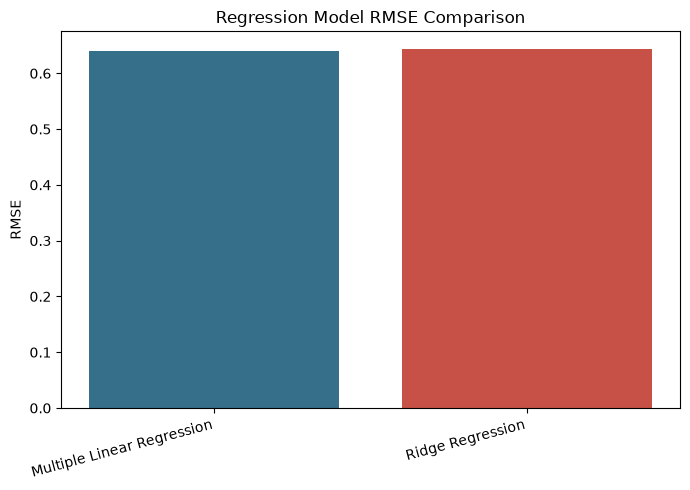

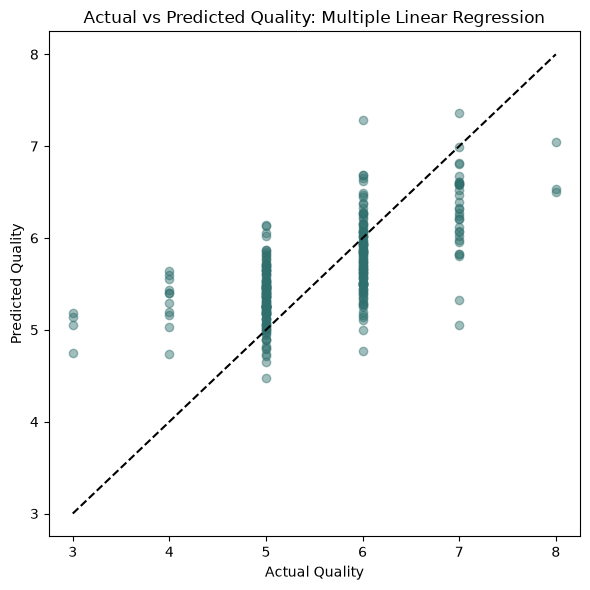

In [4]:
plt.figure(figsize=(7,5))
plt.bar(results_df['model'], results_df['test_rmse'], color=['#356f8a','#c75146'])
plt.title('Regression Model RMSE Comparison')
plt.ylabel('RMSE')
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.savefig(SCREENSHOTS/'d2_rmse_comparison.png', dpi=160)
plt.show()

best_name = results_df.sort_values('test_rmse').iloc[0]['model']
best_model = models[best_name]
pred = best_model.predict(X_test)
plt.figure(figsize=(6,6))
plt.scatter(y_test, pred, alpha=0.45, color='#2f6f6d')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='black', linestyle='--')
plt.xlabel('Actual Quality')
plt.ylabel('Predicted Quality')
plt.title(f'Actual vs Predicted Quality: {best_name}')
plt.tight_layout()
plt.savefig(SCREENSHOTS/'d2_actual_vs_predicted.png', dpi=160)
plt.show()

In [5]:
ridge = models['Ridge Regression']
ridge.fit(X, y)
coef = pd.Series(ridge.named_steps['model'].coef_, index=X.columns).sort_values(key=abs, ascending=False)
coef.head(10).round(4)

alcohol_sulphates_interaction    0.4024
volatile acidity                -0.1952
sulphates                       -0.1637
alcohol                          0.1287
pH                              -0.0718
chlorides                       -0.0584
citric acid                     -0.0512
free_to_total_sulfur_ratio       0.0503
total sulfur dioxide            -0.0382
acid_balance                     0.0251
dtype: float64

## Evaluation Summary
The models produced modest R-squared values, which is expected because sensory quality scores are influenced by factors not fully captured in chemical measurements. Ridge Regression is generally preferred when its RMSE is comparable to or lower than ordinary multiple regression because regularization reduces coefficient instability. Alcohol, sulphates, volatile acidity, density, and engineered acidity/interaction terms are useful predictors to carry forward.

In [6]:
results_df.to_csv('data/deliverable_2_regression_results.csv', index=False)
print('Saved regression results and visualizations.')

Saved regression results and visualizations.
